# Ensemble Learning with Keras & Scikit-Learn

This notebook demonstrates how to combine multiple classifiers into a powerful **ensemble** using `VotingClassifier`. 
We'll train four different models and fuse their predictions through *soft voting* (averaging predicted class probabilities).

### Models in the Ensemble
| # | Classifier | Family | Strengths |
|---|-----------|--------|-----------|
| 1 | **Logistic Regression** | Linear | Fast, interpretable, good baseline |
| 2 | **Random Forest** | Tree-based | Handles non-linear boundaries, robust to noise |
| 3 | **SVM (RBF kernel)** | Kernel method | Excellent for small-to-medium non-linear datasets |
| 4 | **Neural Network (Keras)** | Deep Learning | Universal function approximator, flexible architecture |

**The core idea**: each model captures different patterns in the data. By voting, the ensemble often outperforms any single member.

In [1]:
%pip install scikeras

## 1. Imports

In [2]:
# Data generation and splitting
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score

# Classifiers
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, ClassifierMixin
from scikeras.wrappers import KerasClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Keras
import keras


from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


print(f"Keras version: {keras.__version__}")

Keras version: 3.13.2


## 2. Load & Visualize the Dataset

In [3]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Full dataset:  {X.shape[0]} samples, {X.shape[1]} features")
print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")
print(f"Class balance: {np.bincount(y)}")

Full dataset:  500 samples, 2 features
Training set:  400 samples
Test set:      100 samples
Class balance: [250 250]


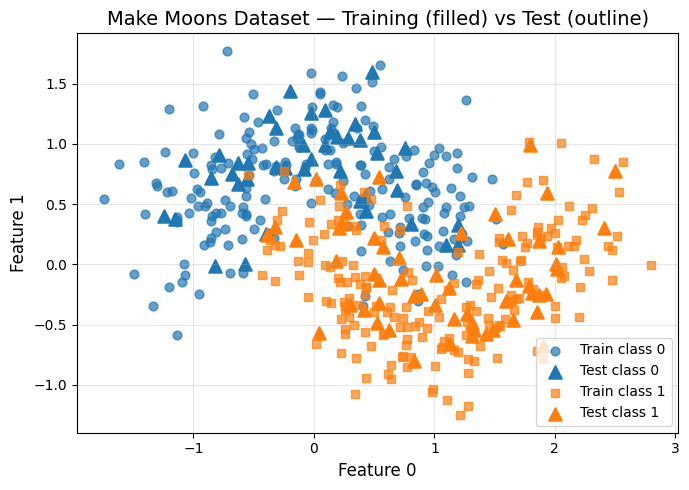

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['tab:blue', 'tab:orange']
markers = ['o', 's']

for label, color, marker in zip([0, 1], colors, markers):
    train_mask = (y_train == label)
    ax.scatter(
        X_train[train_mask, 0], X_train[train_mask, 1],
        c=color, marker=marker, alpha=0.7, s=40, label=f"Train class {label}"
    )
    test_mask = (y_test == label)
    ax.scatter(
        X_test[test_mask, 0], X_test[test_mask, 1],
        c=color, marker='^', facecolors='none', edgecolors=color,
        linewidths=1.5, s=80, label=f"Test class {label}"
    )

ax.set_title("Make Moons Dataset — Training (filled) vs Test (outline)", fontsize=14)
ax.set_xlabel("Feature 0", fontsize=12)
ax.set_ylabel("Feature 1", fontsize=12)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Neural Network Architecture

In [5]:
def build_nn():
    """Two-layer MLP with batch normalization and dropout for regularization."""
    model = keras.Sequential([
        # keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(64, input_dim=100 ,activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [ ]:
keras_clf = KerasClassifier(
    model=build_nn,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    verbose=0,
)

## 4. Train & Evaluate Each Model Individually

In [7]:
classifiers = {
    "Logistic Regression": LogisticRegression(solver="lbfgs", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM (RBF)":          SVC(kernel="rbf", gamma="scale", random_state=RANDOM_STATE, probability=True),
    "Neural Network":     keras_clf,
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    results[name] = {
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall":    round(recall_score(y_test, preds), 4),
        "F1 Score":  round(f1_score(y_test, preds), 4),
    }
    print(f"{name:22s} | Acc={results[name]['Accuracy']:.3f} "
          f"Prec={results[name]['Precision']:.3f} "
          f"Rec={results[name]['Recall']:.3f} "
          f"F1={results[name]['F1 Score']:.3f}")

Logistic Regression    | Acc=0.850 Prec=0.938 Rec=0.789 F1=0.857
Random Forest          | Acc=0.880 Prec=1.000 Rec=0.789 F1=0.882
SVM (RBF)              | Acc=0.870 Prec=1.000 Rec=0.772 F1=0.871


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense' is incompatible with the layer: expected axis -1 of input shape to have value 100, but received input with shape (None, 2)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 2), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
df_metrics = pd.DataFrame(results).T
display(df_metrics)

## 5. Soft-Voting Ensemble

Soft voting averages the **predicted probabilities** from each classifier. 
Every member must support `predict_proba()`.

In [ ]:
krcl = KerasClassifier(model=build_nn, epochs=200, batch_size=32, verbose=0)
voting = VotingClassifier(
    estimators=[
        ("lr",    LogisticRegression(solver="lbfgs", random_state=RANDOM_STATE)),
        ("rf",    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
        ("svc",   SVC(kernel="rbf", gamma="scale", random_state=RANDOM_STATE, probability=True)),
        ("nn",  krcl),  
    ],
    voting="soft",   # average predicted probabilities
    n_jobs=-1,       # fit estimators in parallel
)

voting.fit(X_train, y_train)
voting_preds = voting.predict(X_test)

In [ ]:
results["Ensemble (Soft Vote)"] = {
    "Accuracy":  round(accuracy_score(y_test, voting_preds), 4),
    "Precision": round(precision_score(y_test, voting_preds), 4),
    "Recall":    round(recall_score(y_test, voting_preds), 4),
    "F1 Score":  round(f1_score(y_test, voting_preds), 4),
}

print(f"Ensemble results: {results['Ensemble (Soft Vote)']}")
print(classification_report(y_test, voting_preds, target_names=["Class 0", "Class 1"]))

In [ ]:
df_final = pd.DataFrame(results).T
# Highlight the best value in each metric column
highlighted = df_final.style.highlight_max(axis=0, subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'])
display(highlighted)

## 6. Decision Boundary Visualization

2D contour plots show how each classifier partitions the feature space.

In [ ]:
def plot_decision_boundary(clf, title, ax):
    """Helper: plot contours + data points on a given Axes."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    zz = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    zz = zz.reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=30, cmap="RdYlBu", alpha=0.70)
    for label, color, marker in zip([0, 1], ['tab:blue', 'tab:orange'], ['o', 's']):
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker,
                   s=20, edgecolors='k', linewidths=0.4, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Use the already-trained models from cell 4 + the ensemble from cell 5
trained = {
    "Logistic Regression": classifiers["Logistic Regression"],
    "Random Forest":       classifiers["Random Forest"],
    "SVM (RBF)":          classifiers["SVM (RBF)"],
    "Neural Network":     classifiers["Neural Network"],
    "Ensemble (Soft Vote)": voting,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

names = list(trained.keys())
for i, name in enumerate(names):
    ax = axes[i // 3, i % 3]
    plot_decision_boundary(trained[name], name, ax)

# Hide unused subplot
axes[1, 2].set_visible(False)
fig.suptitle("Decision Boundaries — Individual Models vs Ensemble", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 7. Key Takeaways

1. **Diversity wins** — different algorithms learn complementary decision surfaces.
2. **Soft voting > hard voting** — averaging probabilities retains more information than majority vote.
3. **The ensemble is robust** — its decision boundary typically smooths out the quirks of any single model.
4. **Next steps**: try [Stacking Classifier](https://scikit-learn.org/stable/modules/model_selection.html), add more base learners, or experiment with [cross-val scores](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) for rigorous evaluation.